In [1]:
#%% n body integration
import numpy as np
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import rebound
# from nbody_encounter_funs import *

In [2]:
def calc_params(j, k, mutot, muratio, etilde, pomega12, ecom, pomegacom, acom=None, Tcom=None, deltaT=None):
    ''' Given user inputs as eccentricity vectors, calculates parameters needed to set up the simulation
        Args:
            j: number of orbits for inner planet before conjunction
            k: order of the resonance (ie for 100:99 resonance, order=1)
            mutot: total mass ratio of the planets, (mu1 + mu2) / Mstar
            muratio: ratio of inner planet mass to total planetary mass, m1/(m1 + m2)
            etilde: e12/ec, magnitude of the relative eccentricity vector / crossing eccentricity
            pomega12: angle of the relative eccentricity vector e12
            ecom: magnitude of center of mass eccentricity vector
            pomegacom: angle of center of mass eccentricity vector
            acom: semimajor axis of the center of mass between planets
            Tcom: period of the center of mass between planets
        Returns:
            e1: eccentricity of inner planet
            e2: eccentricity of outer planet
            mu1: mass of inner planet
            mu2: mass of outer planet
            pomega1: pomega of inner planet (ie location angle of pericenter)
            pomega2: pomega of outer planet (ie location angle of pericenter)
            T1: period of inner planet
            T2: period of outer planet
            n10: initial mean motion of inner planet
            n20: initial mean motion of outer planet
            tconj: time between conjunctions
            epsilon: small mass parameter (1/3*mutot)**(1/3)
    '''

    #eccentricity
    ec = 2*k/3/j            # crossing eccentricity
    e12=etilde*ec

    # eccentricity vectors
    e12_vec = e12 * np.exp(1j * pomega12)
    ecom_vec = ecom * np.exp(1j * pomegacom)

    e2_vec = muratio*e12_vec + ecom_vec
    e1_vec = e2_vec - e12_vec

    # planet 1
    e1, pomega1 = np.abs(e1_vec), np.angle(e1_vec)
    mu1 = muratio * mutot    # m1/m_star

    # planet 2
    e2, pomega2 = np.abs(e2_vec), np.angle(e2_vec)
    mu2 = mutot-mu1          # m2/m_star

    # periods
    if Tcom and acom:
        print('Both acom and Tcom specified. \n Used acom = {}'.format(acom))
    elif Tcom: # if specifying Tcom
        T1 = Tcom * (mutot)**(3/2) / (mu1 + mu2*(j/(j-k))**(2/3))**(3/2)
        T2 = T1*j/(j-k)
    elif acom:# if defining acom
        T1 = (acom*mutot*(1/(mu1 + mu2*(j/(j-k))**(2/3))))**(3/2)
        T2 = T1*j/(j-k)
    else: raise Exception('Must specify acom or Tcom')

    # mean motions
    n10 = 2*np.pi/T1        # initial mean motion of inner planet
    n20 = 2*np.pi/T2        # initial mean motion of outer planet

    tconj=(j-k)/k*T1           # time between conjunctions
    epsilon = (mutot/3)**(1/3) # small mass parameter

    return e1, e2, mu1, mu2, pomega1, pomega2, T1, T2, n10, n20, tconj, epsilon

def vecs_from_scalars(mu1, mu2, e1, e2, pomega1, pomega2):
    ''' Given user inputs as info about individual planets, calculates associated vectors
        Args: 
            mu1: total mass ratio of the planets, (mu1 + mu2) / Mstar
            mu2: ratio of inner planet mass to total planetary mass, m1/(m1 + m2)
            e1: eccentricity of inner planet
            e2: eccentricity of outer planet
            pomega1: angle of inner planet pericenter
            pomega2: angle of outer planet pericenter
        Returns:
            mutot: total mass ratio of the planets, (mu1 + mu2) / Mstar
            muratio: ratio of inner planet mass to total planetary mass, m1/(m1 + m2)
            e12: magnitude of the relative eccentricity vector
            pomega12: angle of the relative eccentricity vector e12
            ecom: magnitude of center of mass eccentricity vector
            pomegacom: angle of center of mass eccentricity vector
        '''
    #mass
    mutot = mu1 + mu2
    muratio = mu1 / (mu1 + mu2)

    #eccentricity vectors
    e1_vec = e1*np.exp(1j*pomega1)
    e2_vec = e2*np.exp(1j*pomega2)
    
    e12_vec = e2_vec-e1_vec
    ecom_vec = muratio*e1_vec + (1-muratio)*e2_vec

    # relative vals
    e12 = np.abs(e12_vec)
    pomega12 = np.angle(e12_vec)

    # com vals
    ecom = np.abs(ecom_vec)
    pomegacom = np.angle(ecom_vec)

    return mutot, muratio, e12, pomega12, ecom, pomegacom


def gen_setup(t0, input_vec, correction, theta, to_print=True): # make sim with sim.t = t0 (where conjunction always happens near t=0, use get_conjunction_time to get exact)
    ''' Creates rebound simulation for two planets with the specified masses and eccentricities
        where conjunction occurs near t=0 and the specified angle phi
        Args:
            t0: initial time (ie -.5*t_conj if integrating from -.5*t_conj to +.5*tconj)
            input_vec: output from calc_param function
                       j, k, mutot, muratio, theta, etilde, pomega12, ecom, pomegacom, acom, Tcom
            correction: adjustment added to the input phi value so that simulated phi is closer
                        to the desired input value, obtained from calculate_phi_correction 
            theta: angle of conjunction relative to reference angle pomega12 (theta = l_conj - pomega12)
            etilde: e12/ec, magnitude of the relative eccentricity vector / crossing eccentricity
            to_print: if True, prints the Hill radius separation
    '''
    param_vec = calc_params(*input_vec)
    e1, e2, mu1, mu2, pomega1, pomega2, T1, T2, n10, n20, tconj, epsilon = param_vec

    mutot, muratio, e12, pomega12, ecom, pomegacom = vecs_from_scalars(mu1, mu2, e1, e2, pomega1, pomega2)
    
    sim = rebound.Simulation()
    sim.G = 4*np.pi**2
    sim.add(m=1)
    if e1==0: pomega1=None
    if e2==0: pomega2=None
    sim.add(m=mu1, P=T1, e=e1, pomega=pomega1,
            l=pomega12+(theta-correction)+n10*t0) # theta = l - pomega12, so l = pomega12+theta
    sim.add(m=mu2, P=T2, e=e2, pomega=pomega2, 
            l=pomega12+(theta-correction)+n20*t0)  # initial angle of planet 2 (outer planet)
    ps = sim.particles
    sim.t = t0
    
    if to_print:
        print('Hill radius separation:', (sim.particles[2].a-sim.particles[1].a)/(mutot/3)**(1/3)) # , sim.particles[1].l
    return sim

def calc_theta_corr(input_vec, theta, tmin, tmax, Nout, iterations=3, to_print=False):
    ''' returns a correction to the input theta value, theta_0, so that the simulated theta value from the 
        setup function, theta_sim, matches theta_0.
        Args:
            theta_0: desired theta value (angle of conjunction theta = l_conj - pomega12)
            tmin: initial time of integration
            tmax: final time of integration
            Nout: number of timesteps in the integration
            iterations: number of corrective iterations to perform
            to_print: if True, prints the input and simulated theta values
    '''
    #initializing
    correction = 0
    theta_err = 0

    # iterate to correct for theta value
    for iteration in range(iterations):
        # set up simulation
        theta_input = theta - correction # theta value that goes into sim
        sim = gen_setup(t0=tmin, input_vec=input_vec, correction=correction, theta=theta_input, to_print=False)
        ps = sim.particles

        # integrate through conjunction
        dl, theta_arr = np.zeros(Nout), np.zeros(Nout)
        times = np.linspace(tmin, tmax, Nout)
        for i, time in enumerate(times):
            sim.integrate(time)
            dl[i] = unwrap_l(ps)
            e1_vec_temp= ps[1].e * np.exp(1j * ps[1].pomega)
            e2_vec_temp= ps[2].e * np.exp(1j * ps[2].pomega)
            pomega12_temp = np.angle(e2_vec_temp-e1_vec_temp)
            theta_arr[i] = ps[2].l - pomega12_temp

        # find simulated theta conjunction, compare to input vlaue
        conj_idx = np.argmin(np.abs(dl))
        correction = theta_arr[conj_idx] - theta_input
        theta_err = theta_arr[conj_idx] - theta

    if to_print:
        print('{:9}: {}'.format('Input theta', theta))
        print('{:9}: {}'.format('Sim theta', theta_arr[conj_idx]))
        
    return correction, theta_err # (correction angle and the deviation from the actual theta)

def calc_Delta_a(da_list, conj_idx):
    '''returns change in da from before to after conjunction given list of a values 
       throughout conj'''
    da0_max_idx = np.argmax(da_list[:conj_idx]) # max value of a before conjunction, 
                                                # corresponds to peak just before conj

    daf_max_idx = (np.argmax(da_list[conj_idx:int(1.5*conj_idx)]) # max value of a after conjunction 
                   + conj_idx)                    

    da0 = np.mean(da_list[:da0_max_idx])
    daf = np.mean(da_list[daf_max_idx:]) # fix to find next max 

    Delta_a = daf-da0

    return Delta_a, da0, daf

def unwrap_l(ps):
    ''' given a sim.particles object ps, returns relative lambda (l) value of the planets
        removing the 2*pi discontinuities that result when one planet has crossed l=0 but
        the other has not
    '''
    if ps[2].l - ps[1].l > np.pi:
        return ps[2].l - ps[1].l - 2*np.pi
    elif ps[2].l - ps[1].l < -np.pi:
        return ps[2].l - ps[1].l + 2*np.pi
    else:
        return ps[2].l - ps[1].l

def encounter(input_vec, Nout, int_time_factor, theta):
    '''runs a single encounter and returns list of each orbital element throughout the conjunction'''
    param_vec = calc_params(*input_vec)
    e1, e2, mu1, mu2, pomega1, pomega2, T1, T2, n10, n20, tconj, epsilon = param_vec

    tmin = -int_time_factor*tconj
    tmax = int_time_factor*tconj  
    corr, theta_err = calc_theta_corr(input_vec, theta, tmin, tmax, Nout, iterations=2)
    sim = gen_setup(t0=tmin, input_vec=input_vec, correction=corr, theta=theta)
    ps = sim.particles

    da, dl, l1, theta_arr = np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout)
    times = np.linspace(tmin, tmax, Nout)
    for i, time in enumerate(times):
        sim.integrate(time)
        da[i] = ps[2].a - ps[1].a
        dl[i] = unwrap_l(ps) 
        e1_vec_temp = ps[1].e * np.exp(1j * ps[1].pomega)
        e2_vec_temp = ps[2].e * np.exp(1j * ps[2].pomega)
        pomega12_temp = np.angle(e2_vec_temp-e1_vec_temp)
        theta_arr[i] = ps[2].l - pomega12_temp

        l1[i] = ps[1].l
    
    # conjunction index, angle at conjunction
    conj_idx = np.argmin(np.abs(dl))
    l_conj = l1[conj_idx]
    Delta_a, da0, daf = calc_Delta_a(da, conj_idx)

    return times, da, dl, theta_arr, conj_idx, da0, daf, Delta_a, l_conj



def run(input_vec, Nconj, Nout, theta):
    ''' runs nbody code for Nconj conjunctions and records values at each conjunction'''
    param_vec = calc_params(*input_vec)
    e1, e2, mu1, mu2, pomega1, pomega2, T1, T2, n10, n20, tconj, epsilon = param_vec

    # first conj occurs around t=0, so start a bit before that
    tmin = -0.5*tconj
    tmax = Nconj*tconj + 0.5*tmin

    
    # do not use correction if ecc=0
    corr=0
    if np.real(e2*np.exp(pomega2)-e1*np.exp(pomega1))!=0:
        corr_tmin, corr_tmax = -.8*tconj, .8*tconj
        corr, theta_err = calc_theta_corr(input_vec, theta, corr_tmin, corr_tmax, Nout, iterations=2, to_print=True)

    sim = gen_setup(t0=tmin, input_vec=input_vec, correction=corr, theta=theta)
    ps = sim.particles

    a12_arr, l12_arr, l2, theta_arr, pomega_arr, e12_arr = np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout)
    e1, e2, pomega1, pomega2 = np.zeros(Nout), np.zeros(Nout), np.zeros(Nout), np.zeros(Nout)
    times = np.linspace(tmin, tmax, Nout)
    for i, time in enumerate(times):
        sim.integrate(time)
        a12_arr[i] = (ps[2].a - ps[1].a)/ps[1].a
        l12_arr[i] = unwrap_l(ps) 
        e1_vec_temp= ps[1].e * np.exp(1j * ps[1].pomega)
        e2_vec_temp= ps[2].e * np.exp(1j * ps[2].pomega)
        pomega12_temp = np.angle(e2_vec_temp-e1_vec_temp)
        e12_temp = np.abs(e2_vec_temp-e1_vec_temp)
        theta_arr[i] = ps[2].l - pomega12_temp

        l2[i] = ps[2].l
        pomega_arr[i] = pomega12_temp
        e12_arr[i] = e12_temp

        e1[i] = ps[1].e
        e2[i] = ps[2].e
        pomega1[i] = ps[1].pomega
        pomega2[i] = ps[2].pomega

    l2 = np.unwrap(l2)

    # conjunctions occur at minima pf dl = maxima of -dl
    conj_idx, _ = find_peaks(-np.abs(l12_arr))
    if len(conj_idx) != Nconj:
        print("WARNING: wrong number of conjunction events found \n {} conjunctions found, {} conjunctions input".format(len(conj_idx), Nconj))
        #raise Exception('''wrong number of conjunction events found \n {} conjunctions found, 
        #                {} conjunctions input'''.format(len(conj_idx), Nconj))

    return times, a12_arr, l12_arr, theta_arr, l2, pomega_arr, e12_arr, conj_idx, e1, e2, pomega1, pomega2


def calc_btwn_conj_idx(conj_idx):
    '''returns indices halfway between conjunctions to use for elements that 
    jump at conjunction but are stable between conjunctions'''

    pts_btwn_conj = (.5*np.diff(conj_idx)).astype(np.int64)

    btwn_conj_idx = np.zeros_like(conj_idx)
    btwn_conj_idx[1:] = conj_idx[:-1] + pts_btwn_conj

    return btwn_conj_idx


In [10]:
## how to do without specifying j:k??

phi0 = np.pi
epsilon = 5e-3

# circular massive inner planet
mu1 = 3*epsilon**3
e1 = 0 

# outer tp
mu2 = 0
e2 = 7*epsilon
pomega1 = 0
pomega2 = 0

mutot, muratio, e12, pomega12, ecom, pomegacom =  vecs_from_scalars(mu1, mu2, e1, e2, pomega1, pomega2)
lambda0 = np.pi #np.pi/6       # conjunction angle
theta0 = lambda0-pomega12

Nout = 50000

acom=None
Tcom=1
scalar_params = np.array([e1, e2, mu1, mu2, pomega1, pomega2, theta0, epsilon])

In [4]:
def setup(t0, scalar_params, correction, da):
    e1, e2, mu1, mu2, pomega1, pomega2, theta, epsilon = scalar_params
    pomega12 =  vecs_from_scalars(mu1, mu2, e1, e2, pomega1, pomega2)[3]

    T1 = 1 

    a1 = T1**(2/3)
    a2 = a1 + da
    T2 = a2**(3/2)

    n10 = 2*np.pi/T1        # initial mean motion of inner planet
    n20 = 2*np.pi/T2        # initial mean motion of outer planet

    sim = rebound.Simulation()
    sim.G = 4*np.pi**2
    sim.add(m=1)
    if e1==0: pomega1=None
    if e2==0: pomega2=None
    sim.add(m=mu1, P=T1, e=e1, pomega=pomega1,
            l=pomega12+(theta-correction)+n10*t0) # theta = l - pomega12, so l = pomega12+theta
    sim.add(m=mu2, a=a2, e=e2, pomega=pomega2, 
            l=pomega12+(theta-correction)+n20*t0)  # initial angle of planet 2 (outer planet)
    ps = sim.particles
    sim.t = t0
    return sim

<>:55: SyntaxWarning: invalid escape sequence '\p'
<>:55: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_169141/945415170.py:55: SyntaxWarning: invalid escape sequence '\p'
  ax.set(xlabel='$\\theta = \phi - \lambda_{conj}$', ylabel='$a_r = a_2 - a_1$', title='REBOUND')



 506 conjunctions found, 500 conjunctions input

 514 conjunctions found, 500 conjunctions input

 509 conjunctions found, 500 conjunctions input

 511 conjunctions found, 500 conjunctions input

 516 conjunctions found, 500 conjunctions input

 516 conjunctions found, 500 conjunctions input

 516 conjunctions found, 500 conjunctions input

 516 conjunctions found, 500 conjunctions input

 519 conjunctions found, 500 conjunctions input

 517 conjunctions found, 500 conjunctions input

 521 conjunctions found, 500 conjunctions input

 524 conjunctions found, 500 conjunctions input

 527 conjunctions found, 500 conjunctions input

 529 conjunctions found, 500 conjunctions input

 529 conjunctions found, 500 conjunctions input

 532 conjunctions found, 500 conjunctions input

 532 conjunctions found, 500 conjunctions input

 532 conjunctions found, 500 conjunctions input

 531 conjunctions found, 500 conjunctions input

 535 conjunctions found, 500 conjunctions input

 539 conjunctions f

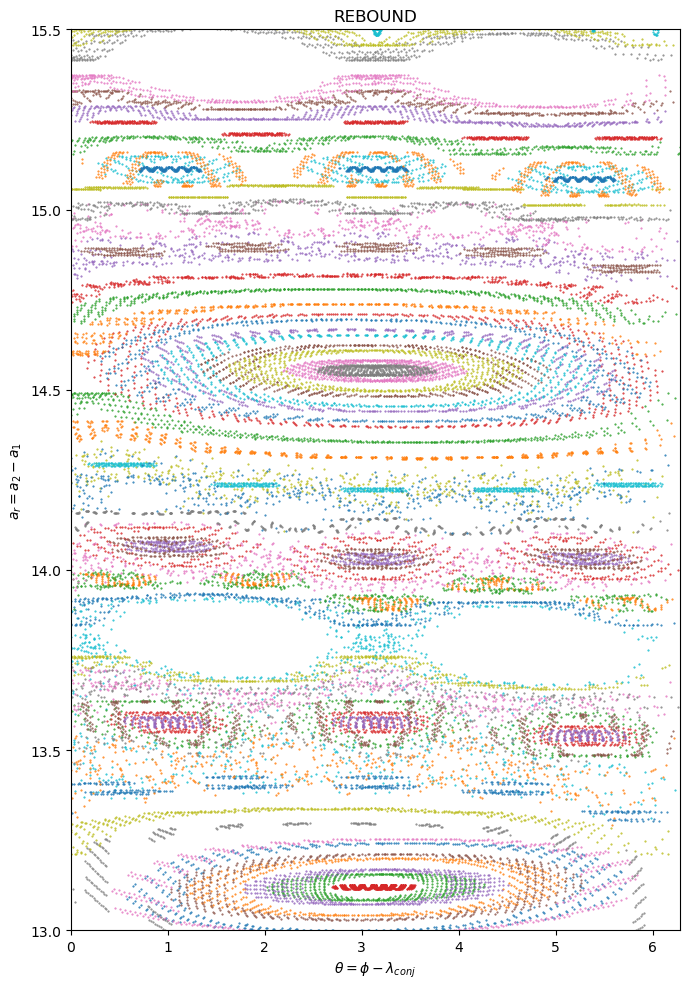

In [25]:
tconj = 11 #(j-k)/k*T1  #HARDCODED? -- this is about a 12:11 resonance
Nconj = 500
Na = 60
tmin = -.5*tconj
tmax = Nconj*tconj + tmin

ar0_list = np.linspace(13, 15.5, Na)
fig, ax = plt.subplots(figsize=(7,10))

for da in ar0_list:
    sim = setup(tmin, scalar_params, 0, da*epsilon)
    ps = sim.particles

    a12_arr, theta_arr, l12_arr = np.zeros(Nout), np.zeros(Nout), np.zeros(Nout)
    times = np.linspace(tmin, tmax, Nout)
    pomega_arr = np.zeros(Nout)
    l2_arr = np.zeros(Nout)
    for i, time in enumerate(times):
        sim.integrate(time)
        a12_arr[i] = (ps[2].a - ps[1].a)/ps[1].a
        l12_arr[i] = unwrap_l(ps) 
        
        e1_vec_temp= ps[1].e * np.exp(1j * ps[1].pomega)
        e2_vec_temp= ps[2].e * np.exp(1j * ps[2].pomega)
        pomega12_temp = np.angle(e2_vec_temp-e1_vec_temp)
        theta_arr[i] = ps[2].l - pomega12_temp
        pomega_arr[i] = pomega12_temp
        l2_arr[i] = ps[2].l
    # conjunctions occur at minima pf dl = maxima of -dl
    conj_idx, _ = find_peaks(-np.abs(l12_arr))
    # then integrate to find actual conjunction
    if len(conj_idx) != Nconj:
        print("\n {} conjunctions found, {} conjunctions input".format(len(conj_idx), Nconj))
    btwn_conj_idx, properties = find_peaks(np.abs(l12_arr))
    theta_conj_gr = theta_arr[conj_idx] > (np.pi)
    theta_conj_less = theta_arr[conj_idx] <= (np.pi)
    #theta_conj = theta_conj_less + (theta_conj_gr-2*np.pi) # bounds from -pi to pi not 0 to 2pi
    pomega_btwn = pomega_arr[btwn_conj_idx]
    lambda_conj = l2_arr[conj_idx]
    #theta_conj = theta_arr[conj_idx]
    a_conj = a12_arr[btwn_conj_idx] / epsilon
    if len(pomega_btwn)==len(lambda_conj):
        theta_conj = lambda_conj-pomega_btwn
    elif len(pomega_btwn)>len(lambda_conj):
        theta_conj = lambda_conj  - pomega_btwn[:-1]
    elif len(pomega_btwn)<len(lambda_conj):
        theta_conj = lambda_conj[:-1] -  pomega_btwn
        
    if len(theta_conj)==len(a_conj):
        ax.plot(theta_conj, a_conj, '.', markersize=1) #if using btwn conj index
    elif len(theta_conj)>len(a_conj):
        ax.plot(theta_conj[:-1], a_conj, '.', markersize=1)
    elif len(theta_conj)<len(a_conj):
        ax.plot(theta_conj, a_conj[:-1], '.', markersize=1)
ax.set(xlabel='$\\theta = \phi - \lambda_{conj}$', ylabel='$a_r = a_2 - a_1$', title='REBOUND')
ax.set_xlim(0, 2*np.pi)
ax.set_ylim(13,15.5)

fig.tight_layout()


#%%
fig.savefig('nbody_cateye.png')
# %%